In [9]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv(
    r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\data\raw\Customer Analytics\bank+marketing\bank-additional\bank-additional\bank-additional-full.csv",
    sep=";",
)

In [11]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Exploratory Data Analysis: Bank Marketing Dataset

This analysis covers dataset structure, data quality, target balance, numerical and categorical distributions, outliers, campaign behavior, previous-contact outcomes, feature relationships, and business-oriented findings.

In [12]:
# 1. Dataset overview and data-quality audit
n_rows, n_cols = df.shape
print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_rate": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
}).sort_values("missing_rate", ascending=False)
display(audit)

print("\nRows with explicit 'unknown' values by column:")
unknown_counts = df.select_dtypes(include="object").apply(
    lambda column: column.astype(str).str.lower().eq("unknown").sum()
    ).sort_values(ascending=False)
display(unknown_counts[unknown_counts > 0].to_frame("unknown_count"))

Rows: 41,188
Columns: 21
Duplicate rows: 12
Memory usage: 9.09 MB


,dtype,missing_count,missing_rate,unique_values
age,int64,0,0.0,78
job,str,0,0.0,12
marital,str,0,0.0,4
education,str,0,0.0,8
default,str,0,0.0,3
housing,str,0,0.0,3
loan,str,0,0.0,3
contact,str,0,0.0,2
month,str,0,0.0,10
day_of_week,str,0,0.0,5



Rows with explicit 'unknown' values by column:


C:\Users\USER\AppData\Local\Temp\ipykernel_12744\3862045015.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  unknown_counts = df.select_dtypes(include="object").apply(


,unknown_count
default,8597
education,1731
housing,990
loan,990
job,330
marital,80


Subscription counts:


,count
y,
no,36548
yes,4640


Subscription rates (%):


,rate
y,
no,88.73
yes,11.27


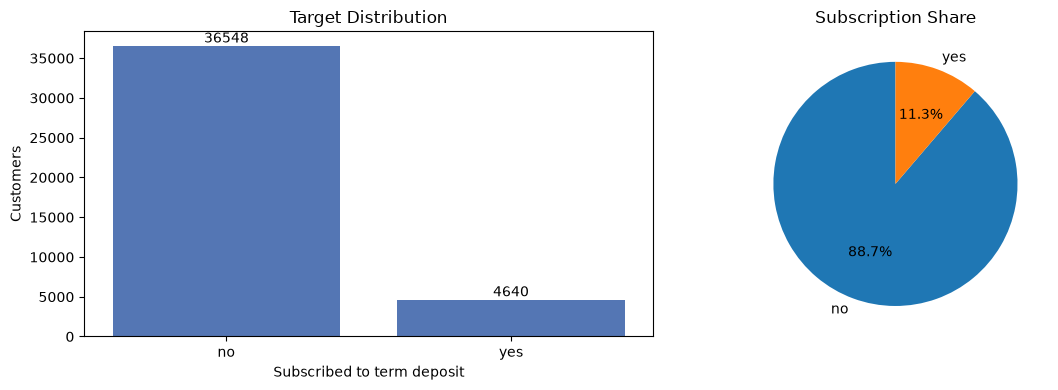

In [13]:
# 2. Target analysis: subscription outcome
target_counts = df["y"].value_counts().reindex(["no", "yes"]).fillna(0)
target_rates = (target_counts / len(df) * 100).round(2)
print("Subscription counts:")
display(target_counts.to_frame("count"))
print("Subscription rates (%):")
display(target_rates.to_frame("rate"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="y", order=["no", "yes"], ax=axes[0], color="#4472C4")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Subscribed to term deposit")
axes[0].set_ylabel("Customers")
for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].pie(target_counts, labels=target_counts.index, autopct="%.1f%%", startangle=90)
axes[1].set_title("Subscription Share")
plt.tight_layout()
plt.show()

In [14]:
# 3. Numerical distributions and outlier review
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
display(df[numeric_cols].describe().T)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis, column in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=column, hue="y", bins=30, element="step", stat="density", common_norm=False, ax=axis)
    axis.set_title(f"{column} distribution")
for axis in axes.flat[len(numeric_cols):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

outlier_rows = []
for column in ["age", "balance", "duration", "campaign", "pdays", "previous"]:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_rows.append({"feature": column, "lower_bound": lower, "upper_bound": upper, "outlier_count": count, "outlier_rate_%": round(count / len(df) * 100, 2)})
print("IQR-based outlier summary:")
display(pd.DataFrame(outlier_rows))

print("pdays sentinel value (-1) rate:", f"{(df['pdays'] == -1).mean() * 100:.2f}%")

KeyError: "['balance', 'day'] not in index"


job - categories: 12


C:\Users\USER\AppData\Local\Temp\ipykernel_12744\3757656007.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = [column for column in df.select_dtypes(include="object").columns if column != "y"]


,customers,subscriptions,subscription_rate_%
job,,,
student,875,275,31.43
retired,1720,434,25.23
unemployed,1014,144,14.20
admin.,10422,1352,12.97
management,2924,328,11.22
unknown,330,37,11.21
technician,6743,730,10.83
self-employed,1421,149,10.49
housemaid,1060,106,10.00



marital - categories: 4


,customers,subscriptions,subscription_rate_%
marital,,,
unknown,80,12,15.00
single,11568,1620,14.00
divorced,4612,476,10.32
married,24928,2532,10.16


...

,customers,subscriptions,subscription_rate_%
month,,,
mar,546,276,50.55
dec,182,89,48.90
sep,570,256,44.91
oct,718,315,43.87
apr,2632,539,20.48
aug,6178,655,10.60
jun,5318,559,10.51
nov,4101,416,10.14
jul,7174,649,9.05



day_of_week - categories: 5


,customers,subscriptions,subscription_rate_%
day_of_week,,,
thu,8623,1045,12.12
tue,8090,953,11.78
wed,8134,949,11.67
fri,7827,846,10.81
mon,8514,847,9.95



poutcome - categories: 3


,customers,subscriptions,subscription_rate_%
poutcome,,,
success,1373,894,65.11
failure,4252,605,14.23
nonexistent,35563,3141,8.83


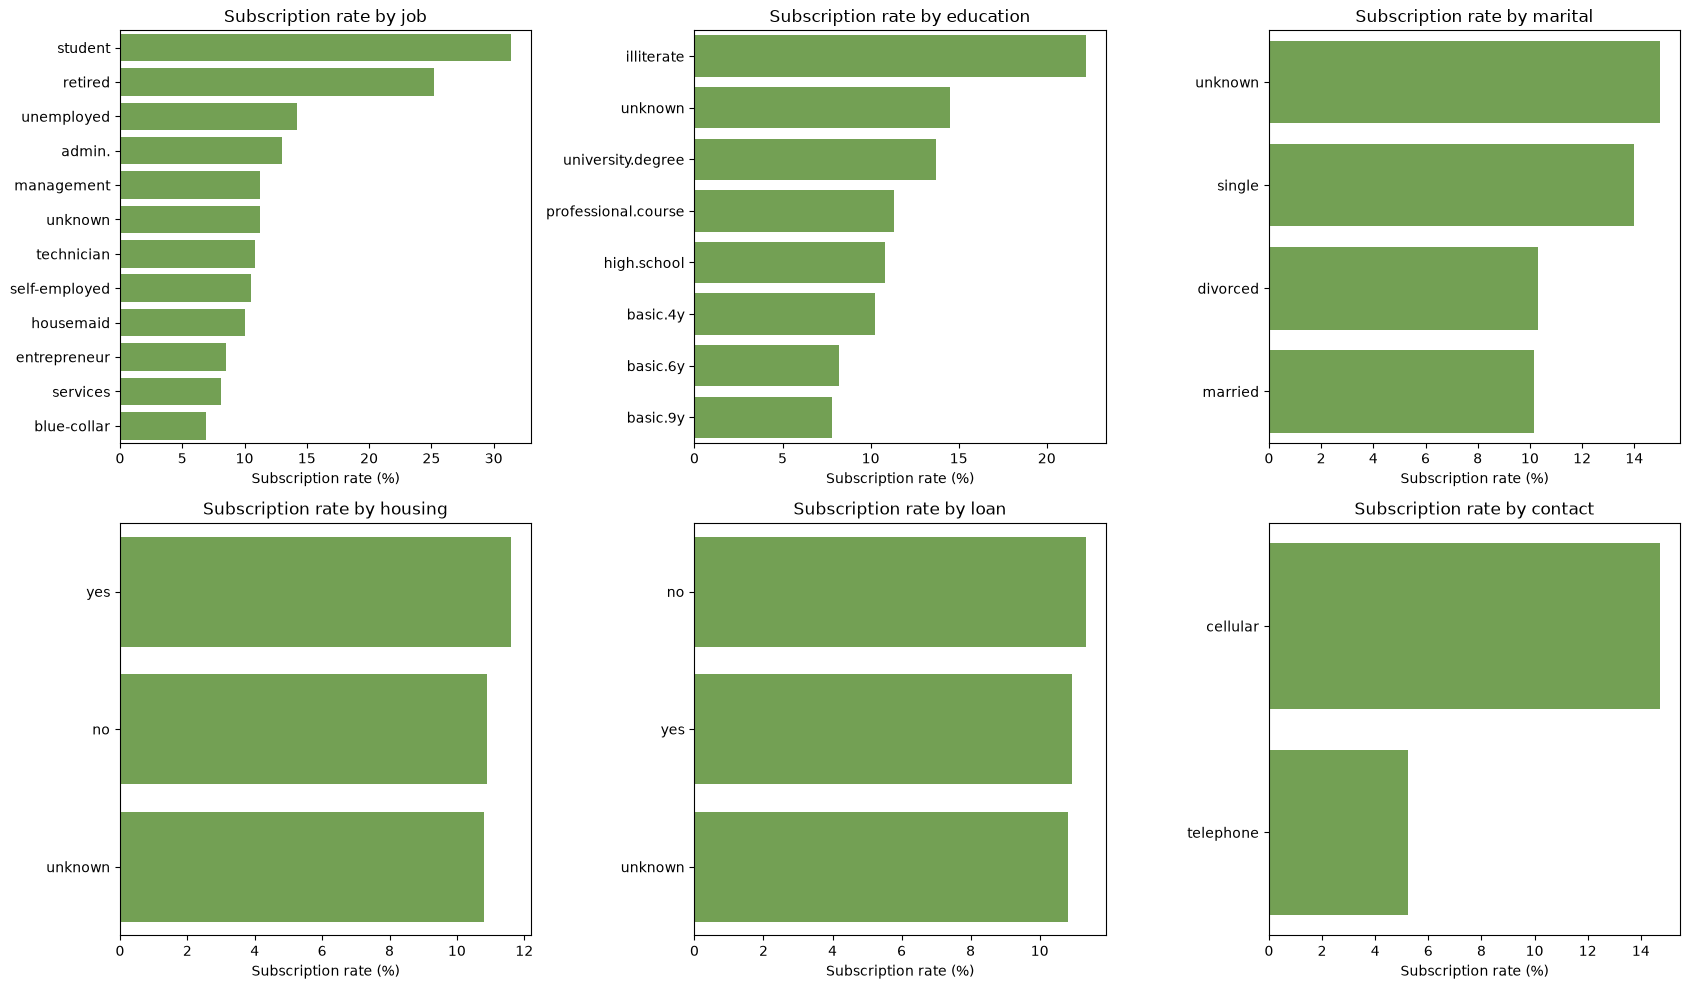

In [16]:
# 4. Categorical feature distributions and conversion rates
categorical_cols = [column for column in df.select_dtypes(include="object").columns if column != "y"]
for column in categorical_cols:
    summary = (
        df.groupby(column, dropna=False)["y"]
        .agg(customers="size", subscriptions=lambda values: (values == "yes").sum())
    )
    summary["subscription_rate_%"] = (summary["subscriptions"] / summary["customers"] * 100).round(2)
    summary = summary.sort_values("subscription_rate_%", ascending=False)
    print(f"\n{column} - categories: {df[column].nunique(dropna=False)}")
    display(summary.head(15))

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
plot_cols = ["job", "education", "marital", "housing", "loan", "contact"]
for axis, column in zip(axes.flat, plot_cols):
    rate = df.groupby(column, dropna=False)["y"].apply(lambda values: (values == "yes").mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=axis, color="#70AD47")
    axis.set_title(f"Subscription rate by {column}")
    axis.set_xlabel("Subscription rate (%)")
    axis.set_ylabel("")
plt.tight_layout()
plt.show()


Month


,customers,subscription_rate_%
month,,
apr,2632,20.48
aug,6178,10.60
dec,182,48.90
jul,7174,9.05
jun,5318,10.51
mar,546,50.55
may,13769,6.43
nov,4101,10.14
oct,718,43.87



Contact


,customers,subscription_rate_%
contact,,
cellular,26144,14.74
telephone,15044,5.23



Campaign Group


,customers,subscription_rate_%
campaign_group,,
1,17642,13.04
2,10570,11.46
3,5341,10.75
4-5,4250,8.68
6-10,2516,6.32
11+,869,3.11



Previous Contact


,customers,subscription_rate_%
previously_contacted,,
1,41188,11.27


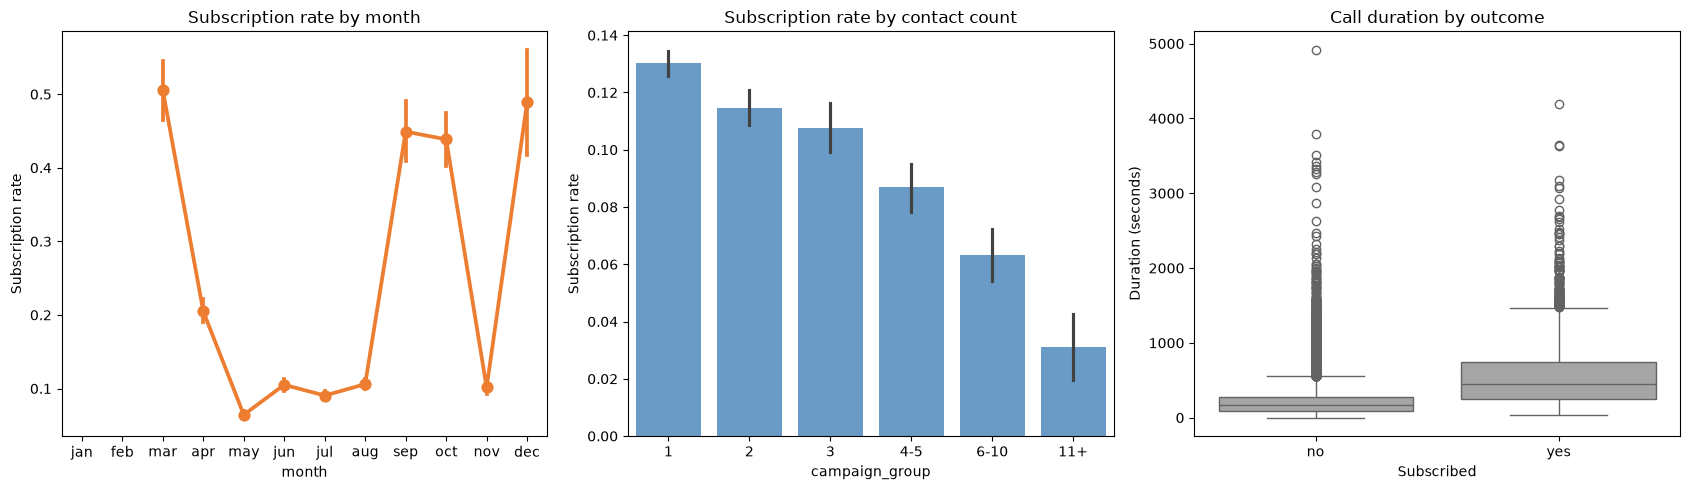

In [17]:
# 5. Campaign and contact-history analysis
df_eda = df.copy()
df_eda["subscribed"] = (df_eda["y"] == "yes").astype(int)
df_eda["previously_contacted"] = (df_eda["pdays"] != -1).astype(int)
df_eda["campaign_group"] = pd.cut(
    df_eda["campaign"],
    bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=["1", "2", "3", "4-5", "6-10", "11+"],
    include_lowest=True,
 )

scenario_tables = {
    "month": df_eda.groupby("month", observed=False)["subscribed"].agg(customers="size", subscription_rate="mean"),
    "contact": df_eda.groupby("contact", observed=False)["subscribed"].agg(customers="size", subscription_rate="mean"),
    "campaign_group": df_eda.groupby("campaign_group", observed=False)["subscribed"].agg(customers="size", subscription_rate="mean"),
    "previous_contact": df_eda.groupby("previously_contacted")["subscribed"].agg(customers="size", subscription_rate="mean"),
}
for name, table in scenario_tables.items():
    table["subscription_rate_%"] = (table["subscription_rate"] * 100).round(2)
    print(f"\n{name.replace('_', ' ').title()}")
    display(table.drop(columns="subscription_rate"))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.pointplot(data=df_eda, x="month", y="subscribed", order=["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"], ax=axes[0], color="#ED7D31")
axes[0].set_title("Subscription rate by month")
axes[0].set_ylabel("Subscription rate")
sns.barplot(data=df_eda, x="campaign_group", y="subscribed", ax=axes[1], color="#5B9BD5")
axes[1].set_title("Subscription rate by contact count")
axes[1].set_ylabel("Subscription rate")
sns.boxplot(data=df_eda, x="y", y="duration", order=["no", "yes"], ax=axes[2], color="#A5A5A5")
axes[2].set_title("Call duration by outcome")
axes[2].set_xlabel("Subscribed")
axes[2].set_ylabel("Duration (seconds)")
plt.tight_layout()
plt.show()

Age-band performance:


,customers,subscription_rate_%
age_band,,
<=25,1666,20.95
26-35,14847,11.72
36-45,12844,8.51
46-55,8249,8.69
56-65,2963,15.22
66+,619,46.85


Numeric correlation with subscription target:


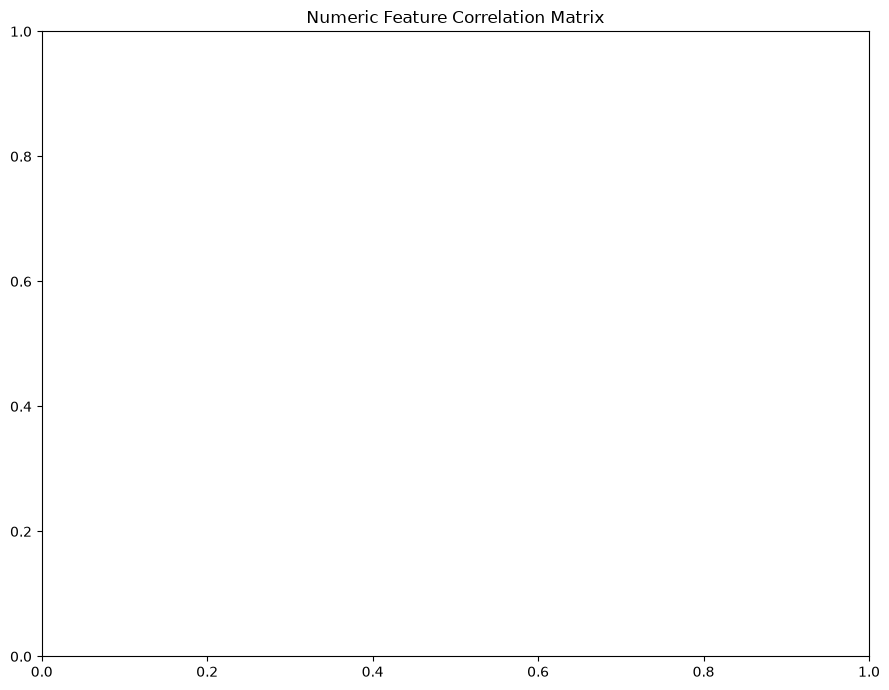

Model-readiness inventory:


,feature,role,type,unique_values,missing_rate_%
0,age,feature,int64,78,0.0
1,job,feature,str,12,0.0
2,marital,feature,str,4,0.0
3,education,feature,str,8,0.0
4,default,feature,str,3,0.0
5,housing,feature,str,3,0.0
6,loan,feature,str,3,0.0
7,contact,feature,str,2,0.0
8,month,feature,str,10,0.0
9,day_of_week,feature,str,5,0.0


In [21]:
# 6. Relationships, interactions, and modelling readiness
df_eda["age_band"] = pd.cut(df_eda["age"], bins=[0, 25, 35, 45, 55, 65, np.inf], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "66+"])
age_table = df_eda.groupby("age_band", observed=False)["subscribed"].agg(customers="size", subscription_rate="mean")
age_table["subscription_rate_%"] = (age_table["subscription_rate"] * 100).round(2)
print("Age-band performance:")
display(age_table.drop(columns="subscription_rate"))

numeric_target_corr = df_eda[numeric_cols + ["subscribed"]].corr(numeric_only=True)["subscribed"].drop("subscribed").sort_values()
print("Numeric correlation with subscription target:")
display(numeric_target_corr.to_frame("correlation"))

plt.figure(figsize=(9, 7))
sns.heatmap(df_eda[numeric_cols + ["subscribed"]].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

model_readiness = pd.DataFrame({
    "feature": df.columns,
    "role": ["target" if column == "y" else "feature" for column in df.columns],
    "type": [str(df[column].dtype) for column in df.columns],
    "unique_values": [df[column].nunique(dropna=False) for column in df.columns],
    "missing_rate_%": [round(df[column].isna().mean() * 100, 2) for column in df.columns],
})
print("Model-readiness inventory:")
display(model_readiness)

## EDA conclusions and next steps

- The target is a customer subscription outcome (`y`), not fraud.
- Check the class imbalance before training; accuracy alone will be misleading if `yes` is the minority class.
- Treat `pdays = -1` as a meaningful "not previously contacted" category rather than an ordinary numeric value.
- Inspect `duration` carefully: it is useful for retrospective analysis but may not be available before a call, so exclude it for a true pre-contact model.
- Encode categorical columns, use stratified train/test splitting, and evaluate with ROC-AUC, precision, recall, F1, and PR-AUC.
- Compare campaign performance by segment, but avoid using post-outreach information when building a model intended to prioritize future customers.